# 01 — Učitavanje i čišćenje podataka

U ovom notebooku učitavam sirovi katalog egzoplaneta sa [exoplanet.eu](https://exoplanet.eu/catalog/),
biram kolone koje su mi potrebne, gledam koliko podataka fali, čistim dataset i čuvam rezultat kao CSV za dalje korake.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 1. Učitavanje dataseta

CSV je skinut direktno sa exoplanet.eu kataloga. Da vidimo šta imamo.

In [2]:
df_raw = pd.read_csv("../data/exoplanet_catalog.csv")
df_raw.head()

,name,planet_status,mass,mass_error_min,mass_error_max,mass_sini,mass_sini_error_min,mass_sini_error_max,radius,radius_error_min,radius_error_max,orbital_period,orbital_period_error_min,orbital_period_error_max,semi_major_axis,semi_major_axis_error_min,semi_major_axis_error_max,eccentricity,eccentricity_error_min,eccentricity_error_max,inclination,inclination_error_min,inclination_error_max,angular_distance,discovered,updated,omega,omega_error_min,omega_error_max,tperi,tperi_error_min,tperi_error_max,tconj,tconj_error_min,tconj_error_max,tzero_tr,tzero_tr_error_min,tzero_tr_error_max,tzero_tr_sec,tzero_tr_sec_error_min,tzero_tr_sec_error_max,lambda_angle,lambda_angle_error_min,lambda_angle_error_max,impact_parameter,impact_parameter_error_min,impact_parameter_error_max,tzero_vr,tzero_vr_error_min,tzero_vr_error_max,k,k_error_min,k_error_max,temp_calculated,temp_calculated_error_min,temp_calculated_error_max,temp_measured,hot_point_lon,geometric_albedo,geometric_albedo_error_min,geometric_albedo_error_max,log_g,publication,detection_type,mass_measurement_type,radius_measurement_type,alternate_names,molecules,star_name,ra,dec,mag_v,mag_i,mag_j,mag_h,mag_k,star_distance,star_distance_error_min,star_distance_error_max,star_metallicity,star_metallicity_error_min,star_metallicity_error_max,star_mass,star_mass_error_min,star_mass_error_max,star_radius,star_radius_error_min,star_radius_error_max,star_sp_type,star_age,star_age_error_min,star_age_error_max,star_teff,star_teff_error_min,star_teff_error_max,star_detected_disc,star_magnetic_field,star_alternate_names
0,109 Psc b,Confirmed,6.800,0.300,0.900,6.3830,0.078,0.078,1.152,NaN,NaN,1075.40,0.7000,0.8000,2.051,0.087,0.079,0.104,0.008,0.009,86.116,20.530,19.957,0.066339,2000,2026-04-03,112.816,5.448,5.254,2451492.00,17.00,17.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114.583,1.196,1.067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Published in a refereed paper,"Radial Velocity, Astrometry",Astrometry,Theoretical,HD 10697 b,NaN,109 Psc,26.232600,20.083150,6.29,NaN,NaN,NaN,NaN,32.5600,0.88000,0.88000,0.10,0.06,0.06,1.13,0.030,0.030,1.790,0.1700,0.1700,G5 IV,6.90,0.60,0.60,5600.0,80.000,80.000,NaN,NaN,HD 10697
1,112 Psc b,Confirmed,NaN,0.005,0.004,0.0330,0.005,0.004,NaN,NaN,NaN,4.40,0.0004,0.0002,0.054,0.002,0.002,0.376,0.254,0.110,NaN,NaN,NaN,NaN,2022,2024-06-14,279.492,67.524,30.206,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Published in a refereed paper,Radial Velocity,Radial Velocity,NaN,HD 12235 b,NaN,112 Psc,30.038165,3.097014,5.88,NaN,5.204,4.63,4.494,31.7627,0.10695,0.10695,0.31,0.10,0.10,1.10,0.133,0.133,1.801,0.0725,0.0725,G0IV,NaN,NaN,NaN,5986.0,105.437,105.437,NaN,NaN,HD 12235
2,112 Psc c,Confirmed,9.866,1.781,3.190,NaN,NaN,NaN,NaN,NaN,NaN,36336.70,6039.4000,9726.0000,22.210,2.766,3.866,0.174,0.154,0.110,47.738,11.804,12.651,NaN,2022,2024-06-14,79.772,31.067,15.493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.503,0.586,1.868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Published in a refereed paper,"Radial Velocity, Astrometry",Astrometry,NaN,HD 12235 c,NaN,112 Psc,30.038165,3.097014,5.88,NaN,5.204,4.63,4.494,31.7627,0.10695,0.10695,0.31,0.10,0.10,1.10,0.133,0.133,1.801,0.0725,0.0725,G0IV,NaN,NaN,NaN,5986.0,105.437,105.437,NaN,NaN,HD 12235
3,11 UMi b,Confirmed,NaN,1.100,1.100,11.0873,1.100,1.100,NaN,NaN,NaN,516.22,3.2500,3.2500,1.540,0.070,0.070,0.080,0.030,0.030,NaN,NaN,NaN,0.012887,2009,2023-03-03,117.630,21.060,21.060,2452861.05,2.06,2.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,189.700,7.150,7.150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Published in a refereed paper,Radial Velocity,Radial Velocity,NaN,NaN,NaN,11 UMi,229.275000,71.823889,5.02,NaN,NaN,NaN,NaN,119.5000,6.90000,6.90000,0.04,0.04,0.04,1.80,0.250,0.250,24.080,1.8400,1.8400,K4III,1.56,0.54,0.54,4340.0,70.000,70.000,NaN,NaN,NaN
4,14 And Ab,Co

In [3]:
df_raw.dtypes

name                              str
planet_status                     str
mass                          float64
mass_error_min                float64
mass_error_max                float64
mass_sini                     float64
mass_sini_error_min           float64
mass_sini_error_max           float64
radius                        float64
radius_error_min              float64
radius_error_max              float64
orbital_period                float64
orbital_period_error_min      float64
orbital_period_error_max      float64
semi_major_axis               float64
semi_major_axis_error_min     float64
semi_major_axis_error_max     float64
eccentricity                  float64
eccentricity_error_min        float64
eccentricity_error_max        float64
inclination                   float64
inclination_error_min         float64
inclination_error_max         float64
angular_distance              float64
discovered                      int64
updated                           str
omega       

## 2. Automatski izbor kolona

Umesto ručnog biranja, filtriramo na redove sa poznatom masom, pa zadržavamo sve kolone koje imaju **>50% popunjenih vrednosti** među tim redovima.

Izbacujemo:
- **Error kolone** (`_error_min`, `_error_max`) — margine greške, ne koristimo ih kao feature-e
- **Data leakage kolone** (`mass_sini`, `k`) — direktno proporcionalne masi
- **Meta kolone** (`updated`, `publication`, `alternate_names`, `molecules`, `star_alternate_names`, `star_detected_disc`, `star_magnetic_field`, `planet_status`, `mass_measurement_type`, `radius_measurement_type`, `star_name`) — identifikatori i metapodaci

In [4]:
EXCLUDE_PATTERNS = ["_error_min", "_error_max"]
LEAKAGE_COLS = ["mass_sini", "mass_sini_error_min", "mass_sini_error_max", "k", "k_error_min", "k_error_max"]
META_COLS = [
    "updated", "publication", "alternate_names", "molecules",
    "star_alternate_names", "star_detected_disc", "star_magnetic_field",
    "planet_status", "mass_measurement_type", "radius_measurement_type", "star_name",
]

drop_cols = set(LEAKAGE_COLS + META_COLS)
for col in df_raw.columns:
    for pattern in EXCLUDE_PATTERNS:
        if pattern in col:
            drop_cols.add(col)

candidates = [c for c in df_raw.columns if c not in drop_cols]
print(f"Kolone posle izbacivanja error/leakage/meta: {len(candidates)} (od {len(df_raw.columns)})")

df_mass_only = df_raw[df_raw["mass"].notna()]
print(f"\nPlanete sa poznatom masom: {len(df_mass_only)}")

THRESHOLD = 0.20
fill_rates = df_mass_only[candidates].notna().mean().sort_values(ascending=False)

kept_cols = fill_rates[fill_rates >= THRESHOLD].index.tolist()
dropped_cols = fill_rates[fill_rates < THRESHOLD].index.tolist()

print(f"\nKolone sa ≥{THRESHOLD*100:.0f}% popunjenih (zadržavamo {len(kept_cols)}):")
for col in kept_cols:
    print(f"  {col:30s} {fill_rates[col]*100:5.1f}%")

print(f"\nKolone sa <{THRESHOLD*100:.0f}% popunjenih (izbacujemo {len(dropped_cols)}):")
for col in dropped_cols:
    print(f"  {col:30s} {fill_rates[col]*100:5.1f}%")

df = df_raw[kept_cols].copy()
print(f"\nDimenzije posle izbora: {df.shape}")

Kolone posle izbacivanja error/leakage/meta: 37 (od 98)

Planete sa poznatom masom: 2349

Kolone sa ≥50% popunjenih (zadržavamo 22):
  name                           100.0%
  mass                           100.0%
  ra                             100.0%
  dec                            100.0%
  discovered                     100.0%
  detection_type                 100.0%
  star_mass                       96.6%
  star_distance                   94.7%
  semi_major_axis                 92.9%
  orbital_period                  85.4%
  star_teff                       83.3%
  star_radius                     82.6%
  star_metallicity                74.8%
  radius                          74.7%
  mag_v                           73.3%
  inclination                     69.5%
  eccentricity                    67.6%
  star_sp_type                    66.2%
  tzero_tr                        60.9%
  star_age                        57.9%
  impact_parameter                54.4%
  temp_calculated          

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6426 entries, 0 to 6425
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              6426 non-null   str    
 1   mass              2349 non-null   float64
 2   ra                6426 non-null   float64
 3   dec               6426 non-null   float64
 4   discovered        6426 non-null   int64  
 5   detection_type    6426 non-null   str    
 6   star_mass         6059 non-null   float64
 7   star_distance     6184 non-null   float64
 8   semi_major_axis   4798 non-null   float64
 9   orbital_period    6075 non-null   float64
 10  star_teff         5902 non-null   float64
 11  star_radius       5788 non-null   float64
 12  star_metallicity  5365 non-null   float64
 13  radius            4901 non-null   float64
 14  mag_v             3532 non-null   float64
 15  inclination       2550 non-null   float64
 16  eccentricity      3148 non-null   float64
 17  star_s

## 3. Analiza nedostajućih vrednosti

Dosta egzoplaneta nema sve izmerene parametre — različite metode detekcije daju različite podatke. Da vidimo koliko fali.

In [6]:
num_of_null_values = df.isnull().sum().sort_values(ascending=False)
num_of_null_values_pct = (num_of_null_values / len(df) * 100)

missing_df = pd.DataFrame({
    "Broj koji fali": num_of_null_values,
    "Procenat koji fali %": num_of_null_values_pct.round(2)
})

missing_df

,Broj koji fali,Procenat koji fali %
tzero_tr,4251,66.15
temp_calculated,4116,64.05
mass,4077,63.45
inclination,3876,60.32
impact_parameter,3583,55.76
eccentricity,3278,51.01
mag_v,2894,45.04
star_age,2768,43.08
star_sp_type,2737,42.59
semi_major_axis,1628,25.33


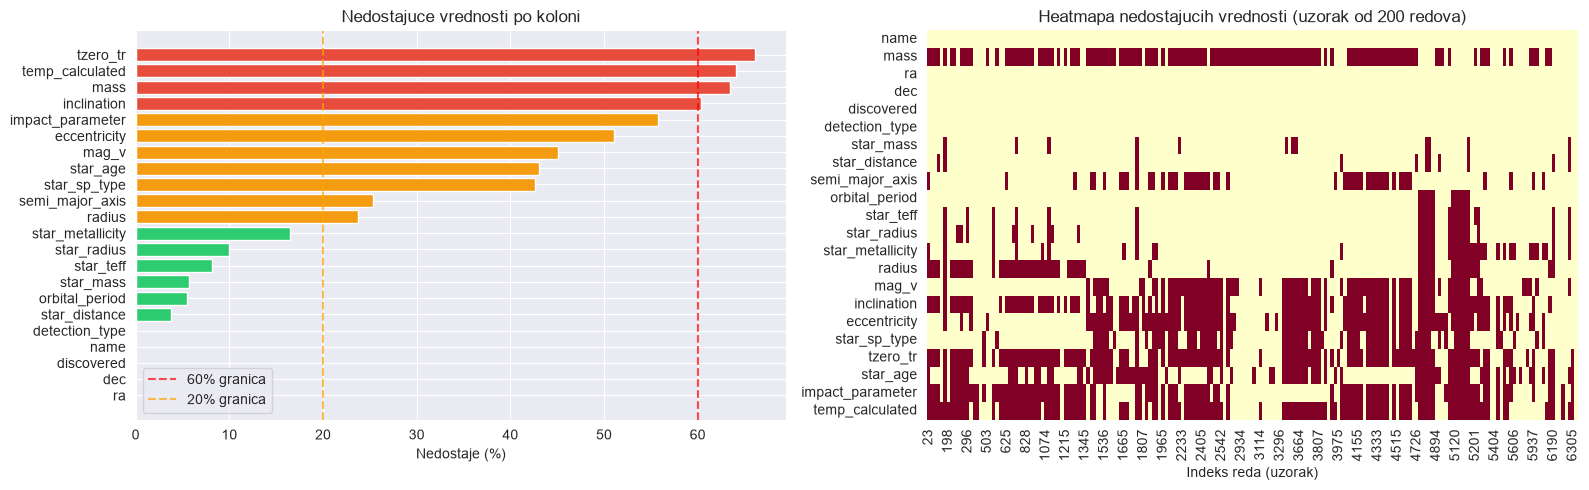

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grafikon
colors = ["#e74c3c" if p > 60 else "#f39c12" if p > 20 else "#2ecc71" for p in num_of_null_values_pct.values]
axes[0].barh(num_of_null_values_pct.index, num_of_null_values_pct.values, color=colors)
axes[0].set_xlabel("Nedostaje (%)")
axes[0].set_title("Nedostajuce vrednosti po koloni")
axes[0].axvline(x=60, color="red", linestyle="--", alpha=0.7, label="60% granica")
axes[0].axvline(x=20, color="orange", linestyle="--", alpha=0.7, label="20% granica")
axes[0].legend()
axes[0].invert_yaxis()

# Heatmapa
sample_idx = np.random.RandomState(42).choice(len(df), size=min(200, len(df)), replace=False)
sample_idx.sort()
sns.heatmap(df.iloc[sample_idx].isnull().T, cbar=False, cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Heatmapa nedostajucih vrednosti (uzorak od 200 redova)")
axes[1].set_xlabel("Indeks reda (uzorak)")

plt.tight_layout()
plt.show()

### Pregled nedostajućih vrednosti u zadržanim kolonama

Kolone sa <50% popunjenosti su već izbačene automatski iznad. Pogledajmo šta fali u preostalim kolonama.

In [8]:
# Sve kolone sa <50% su vec izbacene u koraku 2
# Ovde samo potvrdjujemo sta je ostalo
print(f"Zadrzano kolona: {df.shape[1]}")
print(f"Sve kolone imaju ≥50% popunjenih vrednosti medju planetama sa poznatom masom.")

Zadrzano kolona: 22
Sve kolone imaju ≥50% popunjenih vrednosti medju planetama sa poznatom masom.


## 4. Target varijabla (`mass`)

Oko 63% planeta nema izmerenu masu. Pošto je masa ono što pokušavam da predvidim, ti redovi mi ne trebaju za trening — izbacujem ih. I dalje ostaje ~2300 uzoraka što bi trebalo da bude dovoljno.

In [ ]:
pre_izbacivanja = len(df)
df = df.dropna(subset=["mass"])
print(f"Izbaceno {pre_izbacivanja - len(df)} redova bez mase")
print(f"Preostalo redova: {len(df)}")

## 5. Provera tipova podataka i validacija

Brza provera — da li su numeričke kolone zaista numeričke i da li fizičke veličine imaju smisla (nema negativnih radijusa, ekscentricitet između 0 i 1, itd.).

In [10]:
numericke_kolone = df.select_dtypes(include=[np.number]).columns.tolist()
kategoricke_kolone = df.select_dtypes(include=["str"]).columns.tolist()

print(f"Numericke kolone ({len(numericke_kolone)}): {numericke_kolone}")
print(f"Kategoricke kolone ({len(kategoricke_kolone)}): {kategoricke_kolone}")

Numericke kolone (9): ['mass', 'radius', 'orbital_period', 'semi_major_axis', 'eccentricity', 'star_mass', 'star_radius', 'star_teff', 'star_metallicity']
Kategoricke kolone (3): ['name', 'detection_type', 'star_sp_type']


In [ ]:
# Fizicke velicine koje moraju biti pozitivne
pozitivne_kolone = [c for c in df.select_dtypes(include=[np.number]).columns
                    if c not in ["eccentricity", "star_metallicity", "dec", "ra",
                                 "inclination", "lambda_angle", "omega"]]

for col in pozitivne_kolone:
    n_nevalidnih = (df[col] <= 0).sum()
    if n_nevalidnih > 0:
        print(f"  {col}: {n_nevalidnih} negativnih/nula vrednosti → postavljam na NaN")
        df.loc[df[col] <= 0, col] = np.nan

print("Validacija fizickih vrednosti zavrsena.")

In [12]:
# Ekscentricitet mora biti u opsegu [0, 1)
if "eccentricity" in df.columns:
    n_nevalidnih = ((df["eccentricity"] < 0) | (df["eccentricity"] >= 1)).sum()
    if n_nevalidnih > 0:
        print(f"  eccentricity: {n_nevalidnih} vrednosti van opsega → postavljam na NaN")
        df.loc[(df["eccentricity"] < 0) | (df["eccentricity"] >= 1), "eccentricity"] = np.nan
    print(f"Opseg ekscentriciteta: {df['eccentricity'].min():.4f} — {df['eccentricity'].max():.4f}")

Opseg ekscentriciteta: 0.0000 — 0.9412


## 6. Pregled metoda detekcije

Kratak pogled na to kako su planete otkrivene. Ovo je bitno jer različite metode imaju različite pristrasnosti — npr. tranzit uglavnom nalazi veće planete blizu svoje zvezde.

In [13]:
if "detection_type" in df.columns:
    print("Distribucija metoda detekcije (planete sa poznatom masom):")
    det_counts = df["detection_type"].value_counts()
    print(det_counts)
    print(f"\nUkupno kategorija: {df['detection_type'].nunique()}")

Distribucija metoda detekcije (planete sa poznatom masom):
detection_type
Primary Transit                         1693
Microlensing                             285
Radial Velocity                          140
Radial Velocity, Astrometry               80
Imaging                                   50
TTV                                       24
Timing                                    19
Astrometry                                15
Other                                      8
Radial Velocity, Primary Transit           7
Primary Transit, Radial Velocity           7
Primary Transit, TTV                       4
Imaging, Astrometry                        3
Imaging, Kinematic                         2
Kinematic                                  2
Other, Radial Velocity                     2
Radial Velocity, TTV                       2
Radial Velocity, Astrometry, Imaging       1
Imaging, Other, Kinematic                  1
Imaging, Other                             1
Astrometry, Radial Velocit

## 7. Rezime

In [ ]:
print(f"Dimenzije: {df.shape[0]} redova × {df.shape[1]} kolona")
print(f"\nNumericke kolone ({len(df.select_dtypes(include=[np.number]).columns)}):")
for col in df.select_dtypes(include=[np.number]).columns:
    print(f"  {col}")
print(f"\nKategoricke kolone ({len(df.select_dtypes(include=['object', 'str']).columns)}):")
for col in df.select_dtypes(include=["object", "str"]).columns:
    print(f"  {col}")
print(f"\nTarget (mass) — popunjeno: {df['mass'].notna().sum()}")

In [15]:
df.describe()

,mass,radius,orbital_period,semi_major_axis,eccentricity,star_mass,star_radius,star_teff,star_metallicity
count,2349.000000,1754.000000,2.006000e+03,2182.000000,1587.000000,2268.000000,1940.000000,1956.000000,1756.000000
mean,1.528441,0.707554,3.124920e+03,66.247791,0.116041,0.896659,1.148341,5413.604857,0.044805
std,2.646261,0.548184,7.311178e+04,1818.027182,0.163614,0.380509,1.267935,1937.515736,0.209062
min,0.000190,0.026000,2.444400e-02,0.001390,0.000000,0.011000,0.010000,2560.000000,-0.720000
25%,0.029610,0.211400,3.321318e+00,0.045455,0.000000,0.660000,0.751000,4837.000000,-0.080000
50%,0.381000,0.570000,6.401407e+00,0.079350,0.050000,0.930000,0.990000,5550.000000,0.050000
75%,1.490000,1.151500,2.146813e+01,0.639250,0.161000,1.111000,1.376250,5946.000000,0.190000
max,12.934000,6.900000,2.722900e+06,80679.000000,0.941200,5.500000,35.000000,42065.000000,0.790000


## 8. Čuvanje očišćenog dataseta

Snimam očišćeni dataframe da ga mogu direktno učitati u sledećim notebookovima bez ponavljanja svega ovoga.

In [16]:
output_path = "../data/exoplanet_cleaned.csv"
df.to_csv(output_path, index=False)
print(f"Ocisceni dataset sacuvan u {output_path}")
print(f"Konacne dimenzije: {df.shape[0]} redova × {df.shape[1]} kolona")

Ocisceni dataset sacuvan u ../data/exoplanet_cleaned.csv
Konacne dimenzije: 2349 redova × 12 kolona
